# COVID-QU-Ex Dataset

The researchers of Qatar University have compiled the COVID-QU-Ex dataset. On 25th March 2026 for this study, we chose version 7 (1.21 GB). The dataset consists of 33,920 chest X-ray images across three classes: COVID-19, Non-COVID infections, and Normal. To ensure reproducibility, the exact snapshot was downloaded from url (https://www.kaggle.com/api/v1/datasets/download/anasmohammedtahir/covidqu). All experiments were conducted using this fixed version without additional external data augmentation unless explicitly noted.

The 33,920 chest X-ray consists of following:
- 11,956 COVID-19
- 11,263 Non-COVID infections (Viral or Bacterial Pneumonia)
- 10,701 Normal

The goal of the current study is to classify across three classes using Infection data so we will drop the masks data and lungs data.
It can assist the medical doctors to better diagnose the COVID-19 and follow up the progression of the disease easily.

If you use COVID-QU-Ex Dataset in your research, please consider to cite the publications/dataset below:
[1] A. M. Tahir, M. E. H. Chowdhury, A. Khandakar, Y. Qiblawey, U. Khurshid, S. Kiranyaz, N. Ibtehaz, M. S. Rahman, S. Al-Madeed, S. Mahmud, M. Ezeddin, K. Hameed, and T. Hamid, “COVID-19 Infection Localization and Severity Grading from Chest X-ray Images”, Computers in Biology and Medicine, vol. 139, p. 105002, 2021, https://doi.org/10.1016/j.compbiomed.2021.105002.
[2] Anas M. Tahir, Muhammad E. H. Chowdhury, Yazan Qiblawey, Amith Khandakar, Tawsifur Rahman, Serkan Kiranyaz, Uzair Khurshid, Nabil Ibtehaz, Sakib Mahmud, and Maymouna Ezeddin, “COVID-QU-Ex .” Kaggle, 2021, https://doi.org/10.34740/kaggle/dsv/3122898.
[3] T. Rahman, A. Khandakar, Y. Qiblawey A. Tahir S. Kiranyaz, S. Abul Kashem, M. Islam, S. Al Maadeed, S. Zughaier, M. Khan, M. Chowdhury, "Exploring the Effect of Image Enhancement Techniques on COVID-19 Detection using Chest X-rays Images," Computers in Biology and Medicine, p. 104319, 2021, https://doi.org/10.1016/j.compbiomed.2021.104319.
[4] A. Degerli, M. Ahishali, M. Yamac, S. Kiranyaz, M. E. H. Chowdhury, K. Hameed, T. Hamid, R. Mazhar, and M. Gabbouj, "Covid-19 infection map generation and detection from chest X-ray images," Health Inf Sci Syst 9, 15 (2021), https://doi.org/10.1007/s13755-021-00146-8.
[5] M. E. H. Chowdhury, T. Rahman, A. Khandakar, R. Mazhar, M. A. Kadir, Z. B. Mahbub, K. R. Islam, M. S. Khan, A. Iqbal, N. A. Emadi, M. B. I. Reaz, M. T. Islam, "Can AI Help in Screening Viral and COVID-19 Pneumonia?," IEEE Access, vol. 8, pp. 132665-132676, 2020, https://doi.org/10.1109/ACCESS.2020.3010287.

In [ ]:
import sys

common_modules_path = "/content/drive/MyDrive/ai-projects/2026-03-transfer-learning-resnet-50"
sys.path.append(common_modules_path)
print(f"Updated sys.path: {sys.path}")

In [ ]:
#!/bin/bash
# downlaod dataset zip
!curl -L -o $covidqu_zip_path https://www.kaggle.com/api/v1/datasets/download/anasmohammedtahir/covidqu

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1179M  100 1179M    0     0  19.6M      0  0:01:00  0:01:00 --:--:-- 36.3M


In [ ]:
# Unzip the downloaded file: last took 2663.531s ~ 45 minutes
!unzip -n "$covidqu_zip_path" "Infection Segmentation Data/Infection Segmentation Data/*" -d "$covidqu_path"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/ai-datasets/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/Normal/images/Normal (1767).png  
  inflating: /content/drive/MyDrive/ai-datasets/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/Normal/images/Normal (1768).png  
  inflating: /content/drive/MyDrive/ai-datasets/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/Normal/images/Normal (1769).png  
  inflating: /content/drive/MyDrive/ai-datasets/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/Normal/images/Normal (1770).png  
  inflating: /content/drive/MyDrive/ai-datasets/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/Normal/images/Normal (1771).png  
  inflating: /content/drive/MyDrive/ai-datasets/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/Normal/images/Normal (1772).png  
  inflating: /content/drive/MyDrive/a

In [ ]:
!echo 'Dataset Path is:' $covidqu_path
!ls $covidqu_path -l

Dataset Path is: /content/drive/MyDrive/ai-datasets/covidqu
total 4
drwx------ 3 root root 4096 Mar 26 02:16 'Infection Segmentation Data'


# Remove Masks

In [ ]:
# remove masks from COVID-19
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/lung masks"

!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Train/COVID-19/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Train/COVID-19/lung masks"

!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Val/COVID-19/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Val/COVID-19/lung masks"

# remove masks from Non-COVID
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/lung masks"

!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Train/Non-COVID/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Train/Non-COVID/lung masks"

!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Val/Non-COVID/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Val/Non-COVID/lung masks"

# remove masks from Normal
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Test/Normal/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Test/Normal/lung masks"

!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Train/Normal/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Train/Normal/lung masks"

!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Val/Normal/infection masks"
!rm -r $covidqu_path/"Infection Segmentation Data/Infection Segmentation Data/Val/Normal/lung masks"

# Move Train, Test, and Val at the covidqu dataset path

In [ ]:
!mv "$covidqu_path/Infection Segmentation Data/Infection Segmentation Data/"* $covidqu_path

In [ ]:
# move images in the class folder
!mv "$covidqu_path/Train/COVID-19/images/"* "$covidqu_path/Train/COVID-19"
!rmdir "$covidqu_path/Train/COVID-19/images"

!mv "$covidqu_path/Test/COVID-19/images/"* "$covidqu_path/Test/COVID-19"
!rmdir "$covidqu_path/Test/COVID-19/images"

!mv "$covidqu_path/Val/COVID-19/images/"* "$covidqu_path/Val/COVID-19"
!rmdir "$covidqu_path/Val/COVID-19/images"


!mv "$covidqu_path/Train/Non-COVID/images/"* "$covidqu_path/Train/Non-COVID"
!rmdir "$covidqu_path/Train/Non-COVID/images"

!mv "$covidqu_path/Test/Non-COVID/images/"* "$covidqu_path/Test/Non-COVID"
!rmdir "$covidqu_path/Test/Non-COVID/images"

!mv "$covidqu_path/Val/Non-COVID/images/"* "$covidqu_path/Val/Non-COVID"
!rmdir "$covidqu_path/Val/Non-COVID/images"


!mv "$covidqu_path/Train/Normal/images/"* "$covidqu_path/Train/Normal"
!rmdir "$covidqu_path/Train/Normal/images"

!mv "$covidqu_path/Test/Normal/images/"* "$covidqu_path/Test/Normal"
!rmdir "$covidqu_path/Test/Normal/images"

!mv "$covidqu_path/Val/Normal/images/"* "$covidqu_path/Val/Normal"
!rmdir "$covidqu_path/Val/Normal/images"

# Exploratory Data Analysis

In [ ]:
import os

train_tar_dir = os.path.join(covidqu_path, "Train")
test_tar_dir = os.path.join(covidqu_path, "Test")
val_tar_dir = os.path.join(covidqu_path, "Val")

# list all files
covidqu_images_list = [ os.path.join(p, f) for p, d, files in os.walk(covidqu_path) if not d for f in files]

## Check Images Dimensions

In [ ]:
from PIL import Image
import random


def image_dimensions_check(images_list, sample_size):
  # take random sample to check image dimensions
  sample_list = random.sample(images_list, sample_size)

  dimensions_set = set()
  for img_path in sample_list:
    # open the image
    im = Image.open(img_path)
    dimensions_set.add(im.size)
    # close the image
    im.close()
  return "Same" if len(dimensions_set) else "Not Same"

sample_size = 500
print(f"Image Dimensions across all sets (Train, Test, and Val) and all classes are:\t", image_dimensions_check(covidqu_images_list, sample_size))

Image Dimensions across all sets (Train, Test, and Val) and all classes are:	 Same


## Examine File Format

In [ ]:
from PIL import Image
import random


def image_format_check(images_list, sample_size):
  # take random sample to check image dimensions
  sample_list = random.sample(images_list, sample_size)

  format_set = set()
  for img_path in sample_list:
    format_set.add(img_path.split(".")[-1])
  return format_set

sample_size = 500
print(f"Image file format across all sets (Train, Test, and Val) and all classes are:\t", image_format_check(covidqu_images_list, sample_size))

Image file format across all sets (Train, Test, and Val) and all classes are:	 {'png'}


## Display Image Per Set Per Class

In [87]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

samples_per_class = 5

def display_images(tar_dir, samples_per_class=5, figsize=(12, 8)):
    cls_images = {}
    for p, d, files in os.walk(tar_dir):
        if d:
            continue
        # Handle case where folder has fewer than samples_per_class files
        sample_files = random.sample(files, min(samples_per_class, len(files)))
        for fn in sample_files:
            cls = p.split("/")[-1]
            img_path = os.path.join(p, fn)
            if cls_images.get(cls):
                cls_images[cls].append(img_path)
            else:
                cls_images[cls] = [img_path]

    classes = cls_images.keys()
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=figsize)

    # Add overall title to the figure
    fig.suptitle(f"Sample Images from {tar_dir}", fontsize=20, fontweight='bold', y=1.02)

    for i, (cls_name, img_paths) in enumerate(cls_images.items()):
        for j, img_path in enumerate(img_paths):
            img = Image.open(img_path)
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
        # Put class name as title of first subplot in each row
        axes[i, 0].set_title(cls_name, fontsize=18, loc='left', pad=10)

    plt.tight_layout()
    plt.show()

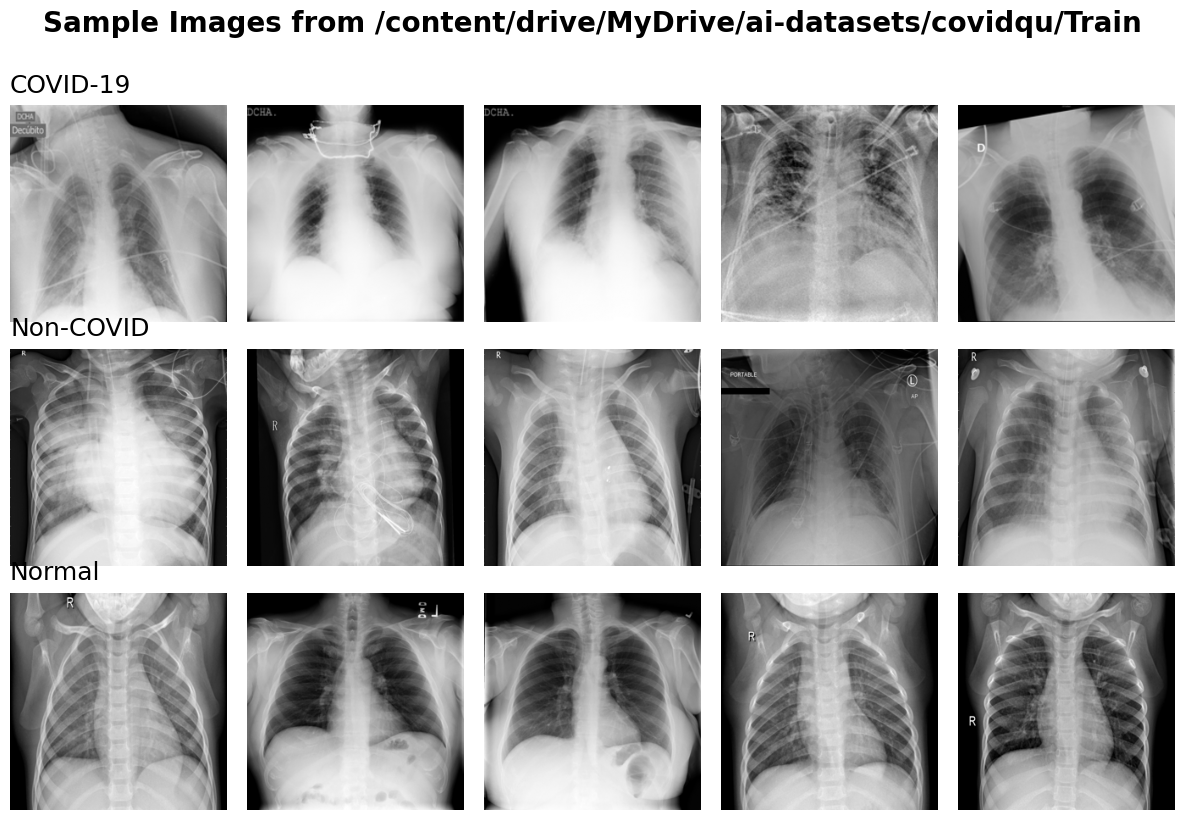

In [89]:
display_images(train_tar_dir, samples_per_class)

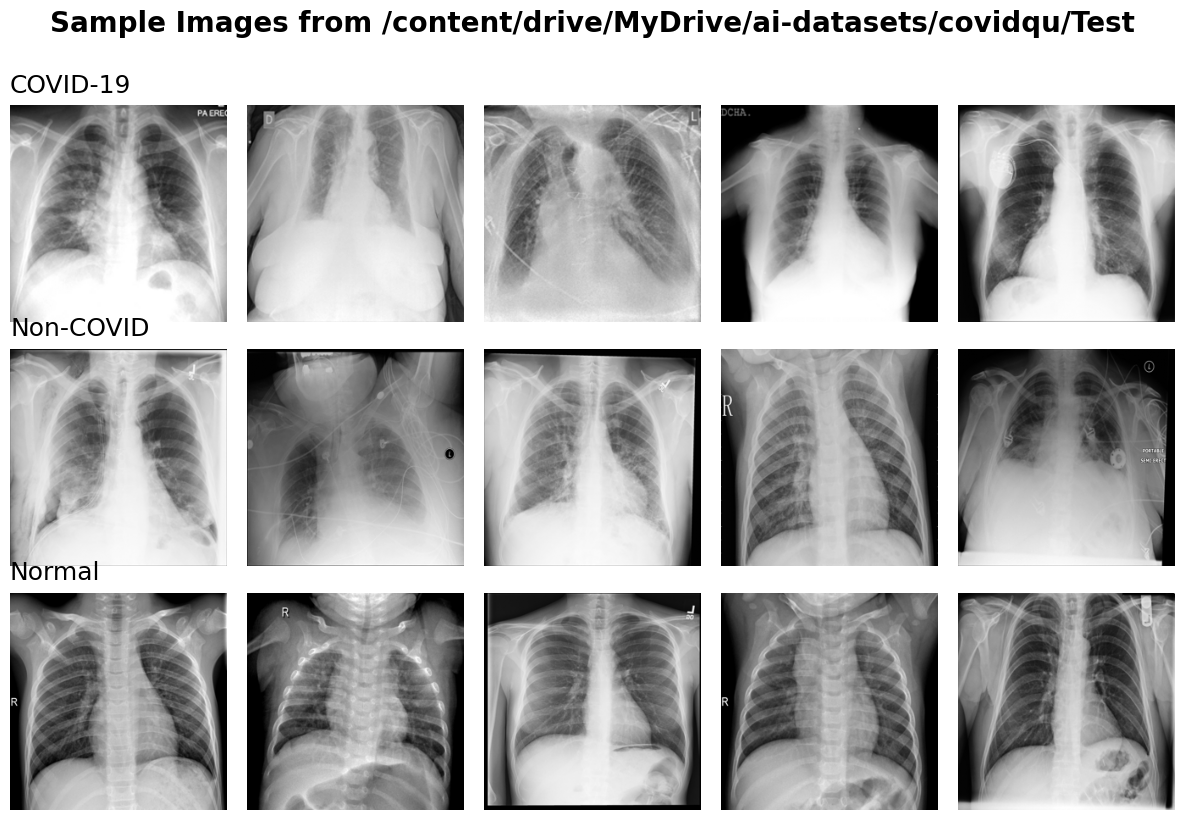

In [90]:
display_images(test_tar_dir, samples_per_class)

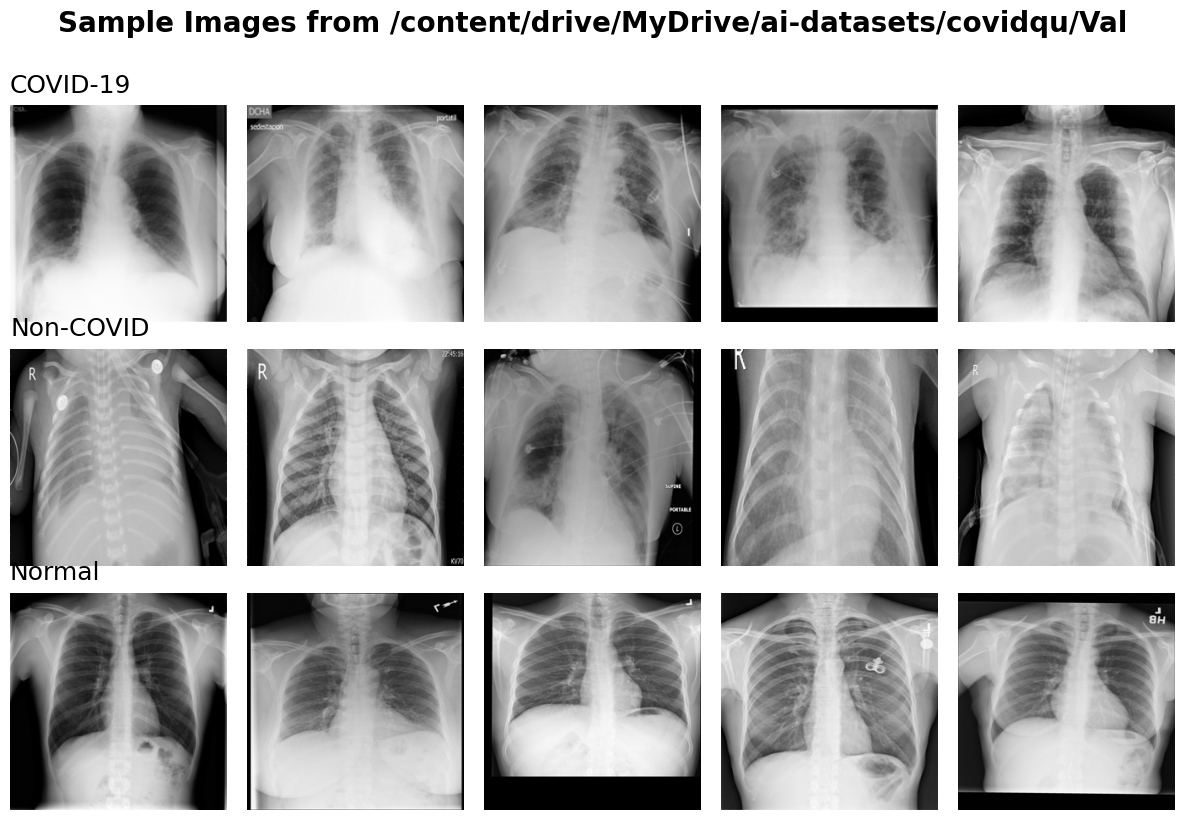

In [91]:
display_images(val_tar_dir, samples_per_class)

## Examine Class Imbalance

In [112]:
import os
from collections import Counter

def check_class_count(data_path):
    class_counts = {}

    for class_name in os.listdir(data_path):
        class_path = os.path.join(data_path, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len([f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return class_counts

def imbalance_report(class_counts, dataset_name):
  total = sum(class_counts.values())
  min_class = min(class_counts, key=class_counts.get)
  max_class = max(class_counts, key=class_counts.get)
  ratio = class_counts[max_class] / class_counts[min_class]

  print(f"""## Dataset Imbalance Analysis: {dataset_name}

  | Metric | Value |
  |--------|-------|
  | Total images | {total} |
  | Number of classes | {len(class_counts)} |
  | Majority class | {max_class} ({class_counts[max_class]} images) |
  | Minority class | {min_class} ({class_counts[min_class]} images) |
  | Imbalance ratio | {ratio:.2f}:1 |

  ### Class Distribution
  """)

  for cls, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
          pct = count/total*100
          print(f"- **{cls}**: {count} ({pct:.1f}%)")

  print(f"""
  ### Implication
  - {'No significant imbalance, standard training acceptable.' if ratio < 1.5 else
    'Moderate imbalance. Consider using class weights or stratified sampling.' if ratio < 3 else
    'Severe imbalance. Must use weighted loss, oversampling, or stratified evaluation.'}
  """)

In [115]:
# calculate Class distribution
class_counts = check_class_count(train_tar_dir)
print("Class distribution:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} images")

Class distribution:
  COVID-19: 1864 images
  Non-COVID: 932 images
  Normal: 932 images


In [116]:
# imbalance report
imbalance_report(class_counts, dataset_name)

## Dataset Imbalance Analysis: COVID-QU-Ex Dataset

  | Metric | Value |
  |--------|-------|
  | Total images | 3728 |
  | Number of classes | 3 |
  | Majority class | COVID-19 (1864 images) |
  | Minority class | Non-COVID (932 images) |
  | Imbalance ratio | 2.00:1 |

  ### Class Distribution
  
- **COVID-19**: 1864 (50.0%)
- **Non-COVID**: 932 (25.0%)
- **Normal**: 932 (25.0%)

  ### Implication
  - Moderate imbalance. Consider using class weights or stratified sampling.
  


In [117]:
import matplotlib.pyplot as plt

def plot_class_balance(class_counts):
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    bars = ax1.bar(classes, counts, color='skyblue', edgecolor='navy')
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Number of Images')
    ax1.set_title('Class Distribution')
    ax1.tick_params(axis='x', rotation=45)

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', va='bottom')

    # Pie chart
    ax2.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Class Distribution (%)')

    plt.tight_layout()
    plt.show()

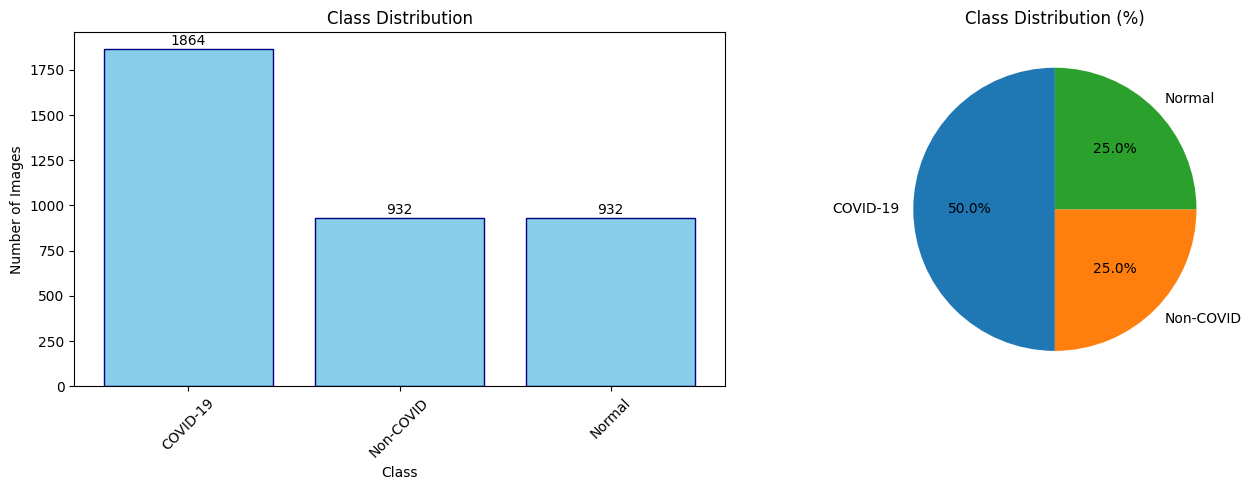

In [119]:
plot_class_balance(class_counts)